<a href="https://colab.research.google.com/github/lukazsw/Machine-Learning-2025L/blob/main/lw430257_homework03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praca Domowa: LAB03_REGRESSION

# Autor: Łukasz Wysocki

Celem tej pracy jest odpowiedź na pytanie:

**Czy próg klasyfikacji 0.5 w regresji logistycznej zawsze jest najlepszym wyborem?**

W pracy sprawdzę, jak zmiana progu decyzyjnego wpływa na działanie modelu klasyfikacyjnego. W tym celu wykorzystam binarny zbiór danych i porównam wyniki modelu dla progu domyślnego oraz progu dobranego na podstawie krzywej ROC.

W pracy wykonam następujące kroki:

- podzielę dane na zbiór treningowy, walidacyjny i testowy,
- wytrenuję model regresji logistycznej,
- na zbiorze walidacyjnym wyznaczę krzywą ROC oraz wartość AUC,
- wybiorę optymalny próg klasyfikacji,
- porównam wyniki na zbiorze testowym dla różnych progów.

W szczególności przeanalizuję wpływ progu na takie miary jak:

- accuracy,
- precision,
- recall,
- F1-score,
- specificity,
- sensitivity.

Na końcu odpowiem również na pytania dotyczące tego, kiedy warto preferować wyższą czułość, a kiedy wyższą swoistość, oraz pokażę, jak krzywa ROC i metryka AUC pomagają w wyborze odpowiedniego progu.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

## Wczytanie danych

W tej pracy użyję zbioru `Diabetes`, czyli standardowego binarnego zbioru danych do klasyfikacji.

Następnie podzielę dane na zbiór treningowy, walidacyjny i testowy oraz wykonam standaryzację cech.

In [37]:
# Load Diabetes dataset from OpenML
data = fetch_openml(name="diabetes", version=1, as_frame=True)

X = data.data
y = data.target

# Convert target to numeric values: tested_positive -> 1, tested_negative -> 0
y = (y == "tested_positive").astype(int)

# Split into train, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape[0])
print("Validation set size:", X_val_scaled.shape[0])
print("Test set size:", X_test_scaled.shape[0])
print("Positive class ratio:", round(y.mean(), 4))

Training set size: 460
Validation set size: 154
Test set size: 154
Positive class ratio: 0.349


## Trenowanie modelu

Teraz wytrenuję model regresji logistycznej na zbiorze treningowym.

Następnie obliczę prawdopodobieństwa dla zbioru walidacyjnego, które będą potrzebne do wyznaczenia krzywej ROC i doboru progu klasyfikacji.

In [38]:
# Train Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=2000)
model.fit(X_train_scaled, y_train)

# Predicted probabilities for the positive class on validation set
y_val_proba = model.predict_proba(X_val_scaled)[:, 1]

print("Model trained successfully.")
print("First 10 predicted probabilities:")
print(np.round(y_val_proba[:10], 4))

Model trained successfully.
First 10 predicted probabilities:
[0.119  0.1363 0.4326 0.068  0.2709 0.1803 0.7161 0.532  0.1839 0.1548]


## Krzywa ROC i AUC

Na zbiorze walidacyjnym wyznaczę teraz krzywą ROC oraz wartość AUC.

Krzywa ROC pokazuje zależność między:
- **TPR (True Positive Rate)**, czyli czułością,
- **FPR (False Positive Rate)**, czyli odsetkiem fałszywie pozytywnych klasyfikacji.

Dzięki temu można sprawdzić, jak zmiana progu wpływa na kompromis między czułością i swoistością.

In [39]:
# Compute ROC curve and AUC on validation set
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
auc_score = roc_auc_score(y_val, y_val_proba)

print("Validation AUC:", round(auc_score, 4))
print("Number of tested thresholds:", len(thresholds))

Validation AUC: 0.8463
Number of tested thresholds: 44


## Wybór optymalnego progu

Aby wybrać próg klasyfikacji, użyję statystyki **Youden's J**:

$$
J = TPR - FPR
$$

Im większa wartość tej statystyki, tym lepszy kompromis między czułością i swoistością.

Na tej podstawie wybiorę próg optymalny na zbiorze walidacyjnym.

In [40]:
# Select optimal threshold using Youden's J statistic
youden_j = tpr - fpr
best_index = np.argmax(youden_j)
best_threshold = thresholds[best_index]

print("Optimal threshold:", round(best_threshold, 4))
print("Best TPR:", round(tpr[best_index], 4))
print("Best FPR:", round(fpr[best_index], 4))
print("Best Youden's J:", round(youden_j[best_index], 4))

Optimal threshold: 0.2896
Best TPR: 0.8889
Best FPR: 0.27
Best Youden's J: 0.6189


## Wizualizacja krzywej ROC

Na wykresie zaznaczę krzywą ROC oraz kilka punktów odpowiadających różnym wartościom progu klasyfikacji.

Dodatkowo wyróżnię próg 0.5 oraz próg optymalny wyznaczony na zbiorze walidacyjnym.

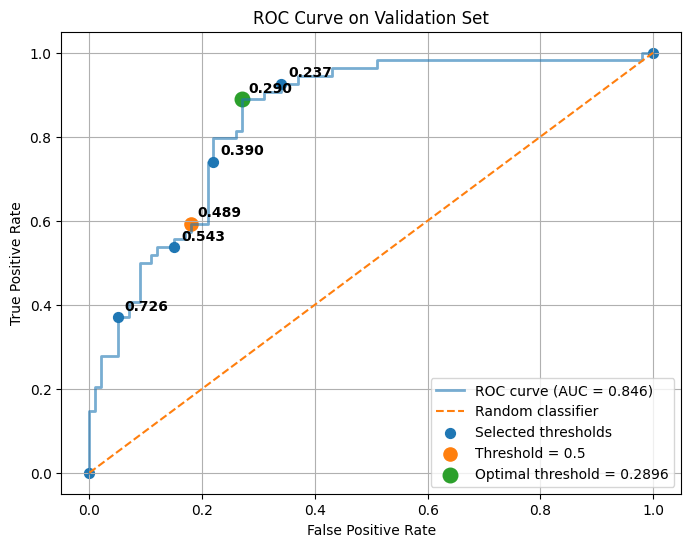

In [41]:
# Find point closest to threshold 0.5
idx_05 = np.argmin(np.abs(thresholds - 0.5))

# Select a few threshold points to mark on the ROC curve
selected_indices = np.linspace(0, len(thresholds) - 1, 6, dtype=int)
selected_indices = np.unique(np.append(selected_indices, [best_index, idx_05]))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, alpha=0.6, linewidth=2, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

# Mark selected threshold points
plt.scatter(fpr[selected_indices], tpr[selected_indices], s=50, label="Selected thresholds")

# Add labels only for meaningful finite thresholds
for i in selected_indices:
    if np.isfinite(thresholds[i]) and 0.01 < thresholds[i] < 0.99:
        plt.annotate(
            f"{thresholds[i]:.3f}",
            (fpr[i], tpr[i]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=10,
            fontweight="bold"
        )

# Highlight threshold 0.5
plt.scatter(
    fpr[idx_05],
    tpr[idx_05],
    s=90,
    label="Threshold = 0.5"
)

# Highlight optimal threshold
plt.scatter(
    fpr[best_index],
    tpr[best_index],
    s=110,
    label=f"Optimal threshold = {best_threshold:.4f}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Validation Set")
plt.legend()
plt.grid(True)
plt.show()

## Ocena modelu na zbiorze testowym

Teraz porównam wyniki modelu na zbiorze testowym dla dwóch progów:
- domyślnego progu `0.5`,
- progu wybranego na podstawie krzywej ROC.

Porównanie wykonam za pomocą miar:
- accuracy,
- precision,
- recall,
- F1-score,
- specificity,
- sensitivity.

In [42]:
def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)  # sensitivity
    f1 = f1_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp)
    sensitivity = recall

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Specificity": specificity,
        "Sensitivity": sensitivity
    }

In [43]:
# Predicted probabilities on test set
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

# Predictions for threshold 0.5
y_test_pred_05 = (y_test_proba >= 0.5).astype(int)

# Predictions for optimal threshold
y_test_pred_opt = (y_test_proba >= best_threshold).astype(int)

metrics_05 = compute_metrics(y_test, y_test_pred_05)
metrics_opt = compute_metrics(y_test, y_test_pred_opt)

In [44]:
results_df = pd.DataFrame(
    [metrics_05, metrics_opt],
    index=["Threshold = 0.5", "Optimal threshold"]
).round(4)

results_df

,Accuracy,Precision,Recall,F1-score,Specificity,Sensitivity
Threshold = 0.5,0.7403,0.6585,0.5094,0.5745,0.8614,0.5094
Optimal threshold,0.6948,0.5385,0.7925,0.6412,0.6436,0.7925


In [45]:
print("Test results comparison:")
print(results_df)

Test results comparison:
                   Accuracy  Precision  Recall  F1-score  Specificity  \
Threshold = 0.5      0.7403     0.6585  0.5094    0.5745       0.8614   
Optimal threshold    0.6948     0.5385  0.7925    0.6412       0.6436   

                   Sensitivity  
Threshold = 0.5         0.5094  
Optimal threshold       0.7925  


## Odpowiedzi na pytania

### Czy próg 0.5 zawsze jest najlepszy?

Nie. W moim modelu próg wybrany na podstawie ROC wyniósł 0.2896, a więc był niższy niż 0.5.

Dla progu 0.5 otrzymałem wyższe:
- accuracy: 0.7403,
- precision: 0.6585,
- specificity: 0.8614.

Dla progu optymalnego otrzymałem wyższe:
- recall / sensitivity: 0.7925,
- F1-score: 0.6412.

To pokazuje, że próg 0.5 nie zawsze daje najlepszy wynik.

### Czy inny próg może dawać lepsze wyniki?

Tak, ale zależy od tego, co uznajemy za „lepsze”.  
W moim przykładzie niższy próg poprawił recall i F1-score, ale pogorszył specificity i precision.

### Jak zmiana progu wpływa na sensitivity i specificity?

- niższy próg $\rightarrow$ wyższa sensitivity, niższa specificity,
- wyższy próg $\rightarrow$ niższa sensitivity, wyższa specificity.

W moich wynikach po obniżeniu progu:
- sensitivity wzrosła z 0.5094 do 0.7925,
- specificity spadła z 0.8614 do 0.6436.

### Co znaczy „lepszy” wynik?

To zależy od zadania:
- jeśli ważne jest wykrycie jak największej liczby pozytywnych przypadków, ważniejszy jest **recall / sensitivity**,
- jeśli ważne jest ograniczenie fałszywych alarmów, ważniejsza jest **specificity** lub **precision**,
- jeśli liczy się kompromis, można patrzeć na **F1-score**.

### Czy najlepszy próg zależy od zadania?

Tak.

- W **wykrywaniu chorób** zwykle ważniejsza jest **czułość**, bo lepiej wykryć więcej chorych osób.
- W **filtrowaniu spamu** często ważniejsza jest **swoistość**, aby poprawne wiadomości nie były oznaczane jako spam.

Dlatego najlepszy próg zależy od zastosowania.

### Jak ROC pomaga w wyborze progu?

Krzywa ROC pokazuje zależność między:
- $TPR$ — True Positive Rate, czyli sensitivity,
- $FPR$ — False Positive Rate, czyli $1 - specificity$.

Każdy punkt odpowiada innemu progowi. Dzięki temu można zobaczyć kompromis między sensitivity i specificity i wybrać próg odpowiedni dla zadania.

### Jak wybrać optymalny próg z ROC?

W tej pracy użyłem statystyki Youden's J:

$$
J = TPR - FPR
$$

Wybrałem próg, dla którego $J$ było największe. Otrzymałem:
- próg: 0.2896,
- $TPR = 0.8889$,
- $FPR = 0.2700$.

### Czym jest AUC i do czego służy?

AUC to pole pod krzywą ROC. Pokazuje, jak dobrze model rozróżnia klasy niezależnie od konkretnego progu.

W moim przypadku:

AUC = 0.8463.

To oznacza, że model dobrze rozdziela klasy. AUC służy do oceny ogólnej jakości klasyfikatora, a ROC pomaga dobrać konkretny próg.

## Wnioski

Próg 0.5 nie zawsze jest najlepszy w regresji logistycznej.

W moim przykładzie próg 0.2896 dawał lepsze recall i F1-score, a próg 0.5 lepsze accuracy, precision i specificity.

Oznacza to, że wybór progu zależy od celu zadania, a krzywa ROC i AUC pomagają ten próg dobrać.